# Regresión lineal simple 

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os
os.chdir("/Users/AlanHDLR/Desktop")

In [13]:
df = pd.read_excel("FuelConsumptionCo2.xlsx")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230


In [15]:
# Exploracion de datos 
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,945.0,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000
mean,2022.0,3.201058,5.670899,12.515767,9.374603,11.102222,27.222222,259.410582
std,0.0,1.374256,1.932837,3.452369,2.290217,2.878074,7.684409,64.486225
min,2022.0,1.200000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000
25%,2022.0,2.000000,4.000000,10.200000,7.700000,9.100000,22.000000,214.000000
50%,2022.0,3.000000,6.000000,12.200000,9.200000,10.800000,26.000000,258.000000
75%,2022.0,3.800000,6.000000,14.700000,10.700000,12.900000,31.000000,301.000000
max,2022.0,8.000000,16.000000,30.300000,20.900000,26.100000,71.000000,608.000000


In [17]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.4,4,8.6,200
1,3.5,6,11.2,263
2,2.0,4,9.9,232
3,2.0,4,10.3,242
4,2.0,4,9.8,230
5,2.0,4,9.8,231
6,3.0,6,11.0,256
7,3.0,6,11.2,261
8,2.0,4,8.7,205


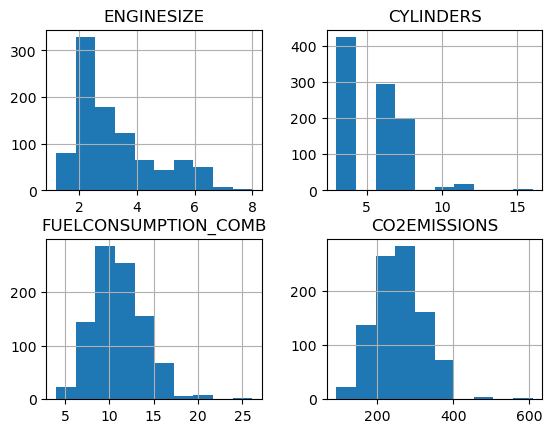

In [19]:
viz = cdf[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
viz.hist()
plt.show()

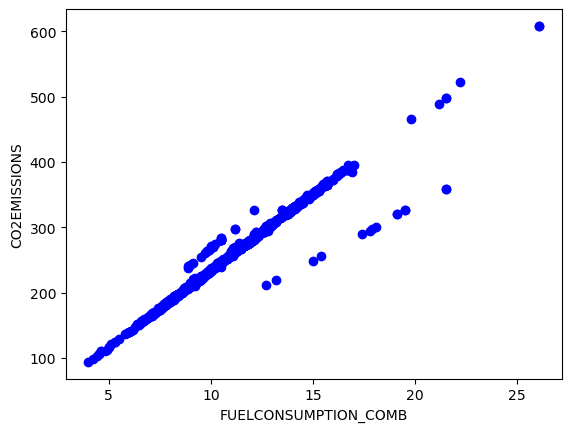

In [21]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.show()

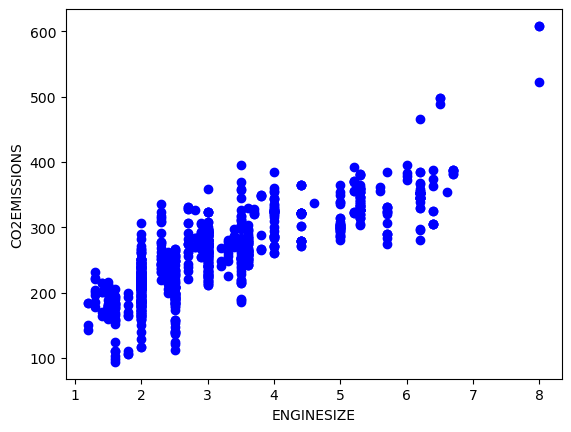

In [23]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

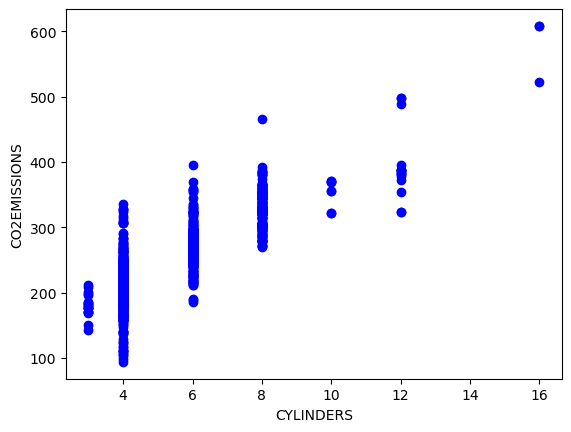

In [25]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('CYLINDERS')
plt.ylabel('CO2EMISSIONS')
plt.show()

In [27]:
# Definimos el grupo de entrenamiento 
msk = np.random.rand(len(df)) <= 0.80
msk

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True, False,
        True,  True, False,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
       False,  True,  True, False,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [29]:
train = cdf[msk]
train

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.4,4,8.6,200
1,3.5,6,11.2,263
2,2.0,4,9.9,232
3,2.0,4,10.3,242
4,2.0,4,9.8,230
...,...,...,...,...
938,2.0,4,9.5,222
939,2.0,4,9.3,217
941,2.0,4,9.4,219
942,2.0,4,9.9,232


In [31]:
# Sacar el complemento del grupo de prueba
test = cdf[~msk]
test

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
7,3.0,6,11.2,261
9,2.0,4,9.2,217
12,2.0,4,9.6,226
16,5.2,12,13.8,324
22,2.0,4,8.9,208
...,...,...,...,...
916,2.0,4,10.6,249
924,1.5,4,6.8,159
929,1.5,4,7.6,178
940,2.0,4,9.4,219


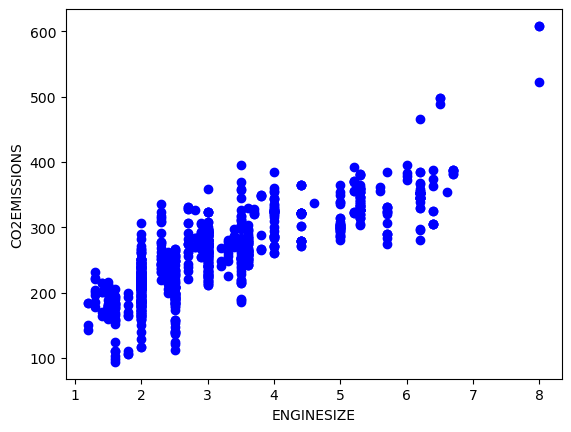

In [33]:
# Modelos de regresion 
# Linea recta que pase por enmedio de todos los puntos 
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

In [35]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)

LinearRegression()

In [36]:
print('Coeficiente de pendiente', regr.coef_)
print('Coeficiente de intercepto', regr.intercept_)

Coeficiente de pendiente [[38.57544684]]
Coeficiente de intercepto [135.50931186]


CO2EMISSIONS = 134.45 + 38.90 * (ENGINESIZE)

Text(0, 0.5, 'Emissions')

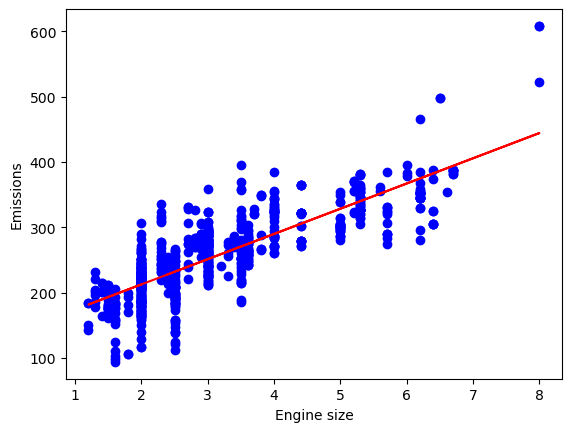

In [40]:
#Colocar la recta encima de los puntos 
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color ='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r' )
plt.xlabel("Engine size")
plt.ylabel("Emissions")

In [42]:
# Evaluación del modelo con los datos al azar
from sklearn.metrics import r2_score
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_hat = regr.predict(test_x)

In [44]:
test_y_hat

array([[251.23565238],
       [212.66020554],
       [212.66020554],
       [336.10163543],
       [212.66020554],
       [336.10163543],
       [289.81109922],
       [212.66020554],
       [247.3781077 ],
       [251.23565238],
       [289.81109922],
       [366.96199291],
       [212.66020554],
       [305.24127796],
       [251.23565238],
       [305.24127796],
       [305.24127796],
       [212.66020554],
       [212.66020554],
       [251.23565238],
       [305.24127796],
       [212.66020554],
       [251.23565238],
       [212.66020554],
       [212.66020554],
       [212.66020554],
       [239.66301833],
       [274.38092049],
       [374.67708228],
       [274.38092049],
       [274.38092049],
       [274.38092049],
       [374.67708228],
       [339.95918012],
       [339.95918012],
       [239.66301833],
       [251.23565238],
       [339.95918012],
       [339.95918012],
       [339.95918012],
       [374.67708228],
       [374.67708228],
       [189.51493744],
       [251

In [46]:
test_y

array([[261],
       [217],
       [226],
       [324],
       [208],
       [322],
       [360],
       [206],
       [254],
       [262],
       [325],
       [373],
       [202],
       [279],
       [296],
       [322],
       [322],
       [213],
       [230],
       [323],
       [321],
       [199],
       [223],
       [209],
       [206],
       [216],
       [233],
       [297],
       [353],
       [251],
       [281],
       [329],
       [297],
       [314],
       [304],
       [328],
       [272],
       [358],
       [359],
       [339],
       [385],
       [366],
       [170],
       [272],
       [332],
       [354],
       [327],
       [332],
       [260],
       [339],
       [363],
       [291],
       [219],
       [198],
       [136],
       [304],
       [256],
       [249],
       [289],
       [274],
       [284],
       [308],
       [344],
       [298],
       [244],
       [291],
       [392],
       [216],
       [252],
       [257],
       [267],
      

In [48]:
# Calcular el valor absoluto de base de prueba contra los reales
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_hat - test_y)))
# Suma de residuales al cuadrado
print("Residuales sum of squares (MSE): %.2f" % np.mean((test_y_hat - test_y) ** 2))
# Valor de r2 al cuadrado
print("R2-score: %.2f" % r2_score(test_y_hat, test_y))

Mean absolute error: 26.49
Residuales sum of squares (MSE): 1134.32
R2-score: 0.58


#  Usamos mas variables para mejorar la presición del modelo

In [50]:
# Como mejorar el nivel de pronostico usando mas variables en ves de solo 1
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.4,4,9.9,7.0,8.6,200
1,3.5,6,12.6,9.4,11.2,263
2,2.0,4,11.0,8.6,9.9,232
3,2.0,4,11.3,9.1,10.3,242
4,2.0,4,11.2,8.0,9.8,230
5,2.0,4,11.3,8.1,9.8,231
6,3.0,6,12.3,9.4,11.0,256
7,3.0,6,12.3,9.8,11.2,261
8,2.0,4,10.0,7.2,8.7,205


In [52]:
# Asi tenemos una matris de 3 variables independientes y 1 dependiente
x = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS','FUELCONSUMPTION_COMB']])
y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (x,y)
print('Coeficientes de variables independientes', regr.coef_)
print('Coeficiente de intercepto', regr.intercept_)

Coeficientes de variables independientes [[ 0.40558894  3.08685477 19.99952968]]
Coeficiente de intercepto [18.55178015]


# CO2EMISSIONS = 19.19360591 + 0.51029172 * (ENGINESIZE) + 2.88662109 * (CYLINDERS) + 20.02711075 + (FUELCONSUMPTION_COMB)

In [55]:
y_hat = regr.predict(test[['ENGINESIZE', 'CYLINDERS','FUELCONSUMPTION_COMB']])
x = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS','FUELCONSUMPTION_COMB']])
y = np.asanyarray(test[['CO2EMISSIONS']])


C:\Users\AlanHDLR\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [57]:
# Calcular el valor absoluto de base de prueba contra los reales
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - y)))
# Suma de residuales al cuadrado
print("Residuales sum of squares (MSE): %.2f" % np.mean((y_hat - y) ** 2))
# Valor de r2 al cuadrado
print("R2-score: %.2f" % r2_score(y_hat, y))

Mean absolute error: 6.95
Residuales sum of squares (MSE): 253.94
R2-score: 0.93


# Otros modelos de regresion 

In [60]:
# Como saber que parametros considera un modelo de regresión en la practica
def pol_grado1(x, Beta_0, Beta_1):
    y = Beta_0 + Beta_1 * x
    return y

In [62]:
x = np.arange(-0.5, 5.0, 0.1)
y = pol_grado1(x, 3, 2)
y_noise = np.random.normal(0, 1, size = x.size)
ydata = y + y_noise

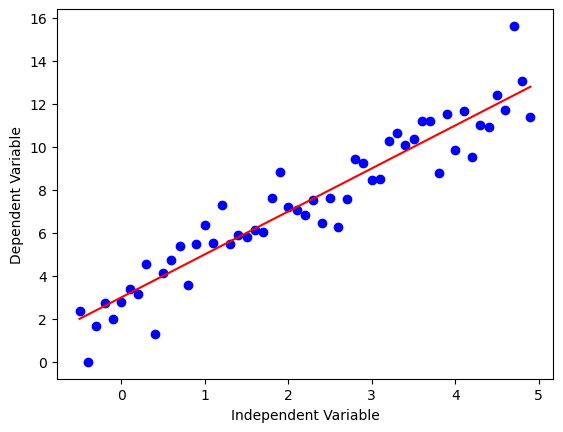

In [64]:
plt.plot(x, ydata, 'bo')
plt.plot(x,y, 'r')
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

In [66]:
# Como tener mejores estimaciones para Beta_0 y Beta_1 sin conocerlos 
from scipy.optimize import curve_fit
popt, pcov = curve_fit(pol_grado1, x, ydata)

In [69]:
print("beta_0 = ", popt[0], "beta_1 = ", popt[1])

beta_0 =  2.909022443941418 beta_1 =  2.029922680482393


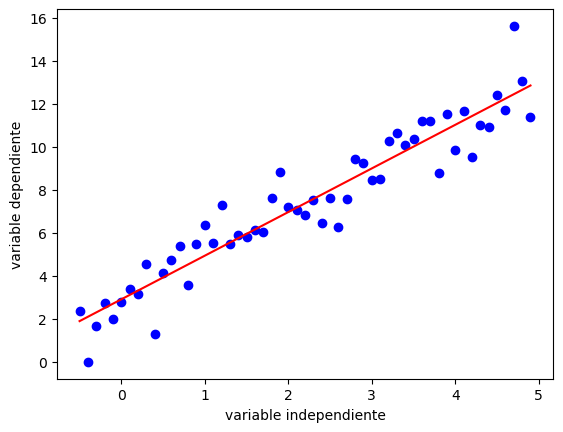

In [71]:
y_ajust = pol_grado1(x, popt[0], popt[1])
plt.plot(x, ydata, 'bo')
plt.plot(x, y_ajust, 'r')
plt.ylabel('variable dependiente')
plt.xlabel('variable independiente')
plt.show()

In [73]:
# Modelo polinomial de tercer grado
def pol_grado3(x, Beta_0, Beta_1, Beta_2, Beta_3):
    y = Beta_0 + Beta_1 * x + Beta_2*(x**2) + Beta_3 * (x**3)
    return y

In [77]:
# Al quere hacer un polinomio tan grande. resulta ser menos util
x = np.arange(-0.5, 5.0, 0.1)
y = pol_grado3(x, 3, 1, 1, 1)
y_noise = 20 * np.random.normal(0, 1, size = x.size)
ydata = y + y_noise

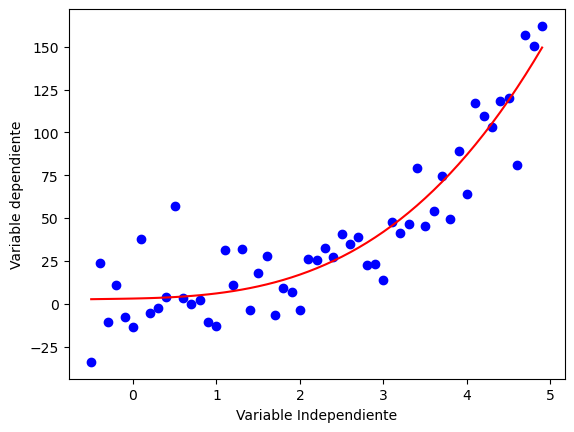

In [79]:
plt.plot(x, ydata, 'bo')
plt.plot(x,y, 'r')
plt.ylabel('Variable dependiente')
plt.xlabel('Variable Independiente')
plt.show()

In [81]:
msk = np.random.rand(len(x)) <= 0.8
msk

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
       False,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True])

In [83]:
train_x = x[msk]
test_x = x[~msk]
train_y = ydata[msk]
test_y = ydata[~msk]

In [85]:
popt, pcov = curve_fit(pol_grado3, train_x, train_y)

In [87]:
print("beta_0 = ", popt[0], "beta_1 = ", popt[1], "beta_2 = ", popt[2], "beta_3 = ", popt[3],)

beta_0 =  2.868343215950012 beta_1 =  13.08150606303172 beta_2 =  -7.983188400106545 beta_3 =  2.419350763401427


In [89]:
# Predicción
y_hat = pol_grado3(test_x, *popt)

In [93]:
# Calcular el valor absoluto de base de prueba contra los reales
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test_y)))
# Suma de residuales al cuadrado
print("Residuales sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
# Valor de r2 al cuadrado
print("R2-score: %.2f" % r2_score(y_hat, test_y))

Mean absolute error: 7.26
Residuales sum of squares (MSE): 81.98
R2-score: 0.94


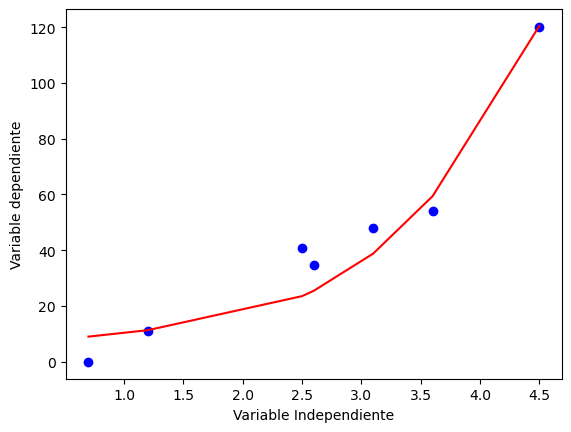

In [97]:
plt.plot(test_x, test_y, 'bo')
plt.plot(test_x, y_hat, 'r')
plt.ylabel('Variable dependiente')
plt.xlabel('Variable Independiente')
plt.show()

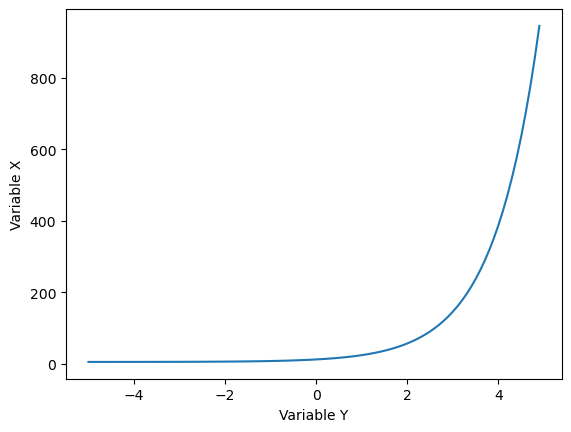

In [103]:
# Modelo exponencial
# Y = a + b *exp(X)

X = np.arange(-5.0, 5.0, 0.1)
Y = 5 + 7 * np.exp(X)

plt.plot(X,Y)
plt.ylabel('Variable X')
plt.xlabel('Variable Y')
plt.show()

C:\Users\AlanHDLR\AppData\Local\Temp\ipykernel_14620\1704635855.py:4: RuntimeWarning: invalid value encountered in log
  Y = 2 + 6 * np.log(X)


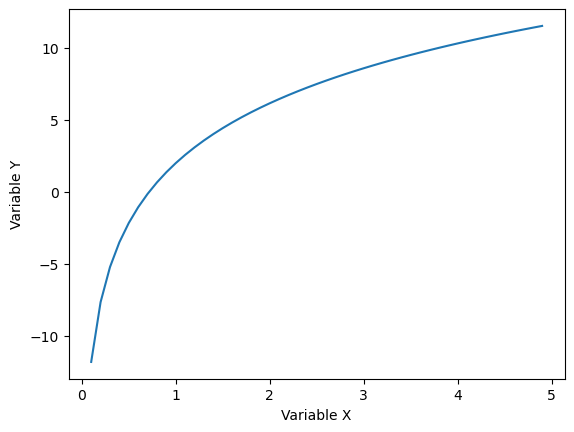

In [107]:
# Modelo logaritmico

X = np.arange(-5.0, 5.0, 0.1)
Y = 2 + 6 * np.log(X)
plt.plot(X,Y)
plt.ylabel('Variable Y')
plt.xlabel('Variable X')
plt.show()

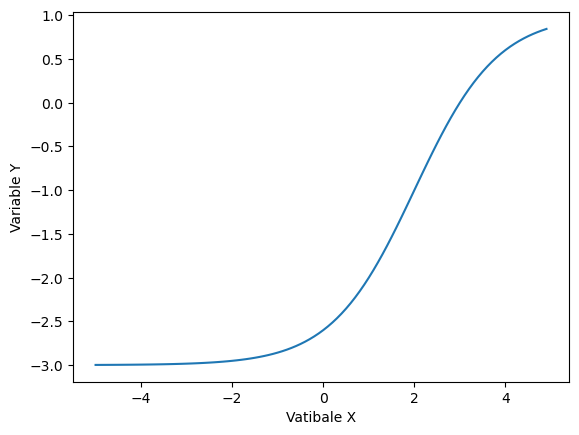

In [109]:
# Modelo Sigmoideal o logistico
 # Y = a + (b / (1 + c ** (X -d)))

X = np.arange(-5.0, 5.0, 0.1) 
Y = 1-4 / (1 +np.power(3, X-2))

plt.plot(X,Y)
plt.ylabel('Variable Y')
plt.xlabel('Vatibale X')
plt.show()